> Organized from the original notebook. Saved outputs are historical and have not been regenerated. See `docs/analysis.md` before interpreting results.


In [ ]:
from pathlib import Path
import sys

PROJECT_ROOT = next(
    (p for p in (Path.cwd(), *Path.cwd().parents) if (p / "project_paths.py").is_file()),
    None,
)
if PROJECT_ROOT is None:
    raise RuntimeError("Launch Jupyter inside the Cancer-overview-ml project.")
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
from project_paths import *
ensure_directories()


In [23]:
import pandas as pd

In [24]:
cooccur = pd.read_csv(MATRIX_FILE)

In [25]:
cooccur

,name,0,1,2,3,4,5,6,7,8,...,2275,2276,2277,2278,2279,2280,2281,2282,2283,2284
0,cancer,7,38,57,7,7,7,7,7,25,...,42,53,38,6,24,20,76,16,23,21
1,tumor,0,5,1,0,0,0,0,0,16,...,1,2,3,0,2,1,5,0,0,0
2,cell,0,6,1,0,0,0,0,0,15,...,1,7,5,0,4,2,11,0,4,0
3,therapy,0,5,4,0,0,0,0,0,10,...,0,11,10,0,3,1,8,0,3,1
4,drug,1,0,1,1,1,1,1,1,18,...,0,1,4,2,2,1,0,0,25,23
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37963,detection genetic medicine cancer,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
37964,prevention detection genetic medicine,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
37965,cancer prevention detection genetic,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
37966,late cancer prevention detection,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [26]:
temp_cooccur = cooccur.drop(columns=["name"],axis=1)

k=50: variance=0.9785
k=100: variance=0.9886
k=150: variance=0.9925
k=200: variance=0.9946
k=250: variance=0.9960
k=300: variance=0.9969


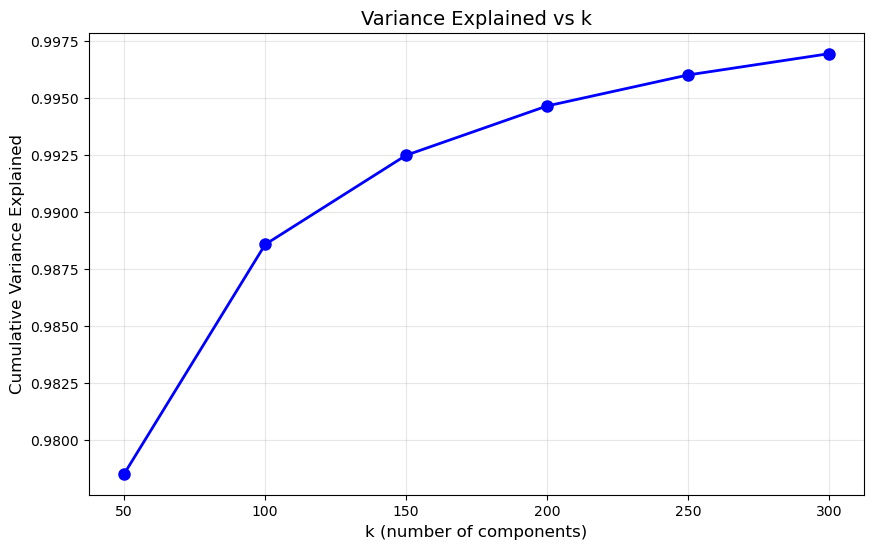

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import Normalizer
from scipy.sparse import csr_matrix
k_values = [50, 100, 150, 200, 250, 300]
variance_scores = []

for k in k_values:
    svd_temp = TruncatedSVD(n_components=k, random_state=42)
    svd_temp.fit(temp_cooccur)
    variance_scores.append(svd_temp.explained_variance_ratio_.sum())
    print(f"k={k}: variance={variance_scores[-1]:.4f}")

plt.figure(figsize=(10, 6))
plt.plot(k_values, variance_scores, 'b-o', linewidth=2, markersize=8)
plt.xlabel('k ', fontsize=12)
plt.ylabel('Cumulative Variance Explained', fontsize=12)
plt.title('Variance Explained vs k', fontsize=14)
plt.grid(True, alpha=0.3)
plt.show()


In [ ]:

from scipy.sparse import csr_matrix
from sklearn.decomposition import TruncatedSVD
import numpy as np
                                      
svd = TruncatedSVD(n_components=100, random_state=10)
X_emb = svd.fit_transform(temp_cooccur)      


In [29]:
pd.DataFrame(X_emb)

,0,1,2,3,4,5,6,7,8,9,...,90,91,92,93,94,95,96,97,98,99
0,2912.694092,1124.828735,1123.975464,620.501221,-653.774597,-456.193939,-76.344116,-167.102402,225.676270,6.085669,...,4.755385,-2.333328,-0.050129,-1.403943,0.854620,-2.364618,-0.668066,-2.088260,-1.284010,0.047771
1,1248.954834,-525.993530,-10.920415,-47.066456,-120.268143,-113.687523,167.969925,620.115173,227.280212,157.477432,...,5.583495,-9.867059,-7.786095,11.592257,-3.681280,-5.345750,0.244094,6.332147,-0.313095,-0.973885
2,831.438843,-480.445953,-188.482330,-204.307388,-393.124939,2.712139,347.778229,-37.589359,193.883835,110.312698,...,-2.866856,-1.641934,4.686439,0.169270,-0.982477,0.399448,3.785809,-4.345933,2.696268,3.449256
3,1315.736206,923.669617,255.257874,-614.612122,31.305216,43.337944,248.399948,-11.466643,-178.391464,9.822622,...,3.456048,3.140234,-3.820812,-7.961269,-2.571227,-7.080045,-1.410276,3.227957,-5.964777,2.329489
4,69.475479,22.566175,49.857903,-21.146599,-96.433662,-22.947550,21.217672,-13.203021,22.997942,-7.657685,...,-9.300846,6.432200,-1.401768,7.597496,-17.105787,-4.271311,3.353717,-1.768055,8.028625,25.147879
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37963,0.743997,0.473862,0.905969,-0.188958,-2.879089,-1.157757,1.966674,-0.079978,0.861775,-0.427981,...,-0.428668,0.598537,0.288124,-0.002248,0.385405,-0.350330,0.112320,-0.119772,0.179271,0.060265
37964,0.743997,0.473862,0.905969,-0.188958,-2.879089,-1.157757,1.966674,-0.079978,0.861775,-0.427981,...,-0.428668,0.598537,0.288124,-0.002248,0.385405,-0.350330,0.112320,-0.119772,0.179271,0.060265
37965,0.743997,0.473862,0.905969,-0.188958,-2.879089,-1.157757,1.966674,-0.079978,0.861775,-0.427981,...,-0.428668,0.598537,0.288124,-0.002248,0.385405,-0.350330,0.112320,-0.119772,0.179271,0.060265
37966,0.743997,0.473862,0.905969,-0.188958,-2.879089,-1.157757,1.966674,-0.079978,0.861775,-0.427981,...,-0.428668,0.598537,0.288124,-0.002248,0.385405,-0.350330,0.112320,-0.119772,0.179271,0.060265


In [30]:
from sklearn.preprocessing import normalize
from sklearn.neighbors import NearestNeighbors

terms = cooccur['name'].to_numpy()
Xn = normalize(X_emb) 

k = 10 
nn = NearestNeighbors(n_neighbors=k+1, metric='cosine').fit(Xn) 
dist, ind = nn.kneighbors(Xn)
len(dist)

37968

In [31]:
rows = []
for i, term in enumerate(terms):
    nbr_idx = ind[i][1:]               
    nbr_dist = dist[i][1:]
    sim = 1.0 - nbr_dist           
    for rank, (j, s) in enumerate(zip(nbr_idx, sim), start=1):
        rows.append((term, terms[j], rank, float(s)))

neighbors_df = pd.DataFrame(rows, columns=["term", "neighbor", "rank", "cosine_sim"])


In [32]:
neighbors_df

,term,neighbor,rank,cosine_sim
0,cancer,canc,1,0.999425
1,cancer,age,2,0.870879
2,cancer,rev,3,0.867938
3,cancer,sel,4,0.867757
4,cancer,rem,5,0.865697
...,...,...,...,...
379675,prognosis chance recovery option,factor prognosis chance,6,0.967794
379676,prognosis chance recovery option,prognosis chance recovery,7,0.966925
379677,prognosis chance recovery option,prognosis chance,8,0.966925
379678,prognosis chance recovery option,chance recovery,9,0.966897


In [33]:
neighbors_df.to_csv(NEIGHBORS_FILE,index=False)